In [ ]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check missing values created
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

Missing TotalCharges: 11


In [ ]:
# Remove rows with missing TotalCharges
df = df.dropna(subset=["TotalCharges"])

print("New Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())

New Shape: (7032, 21)
Missing Values: 0


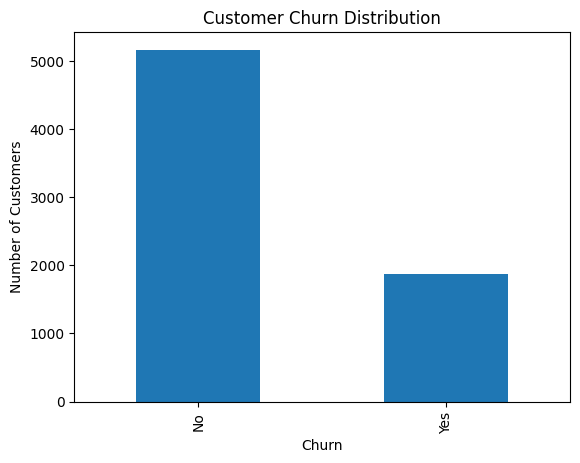

In [ ]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

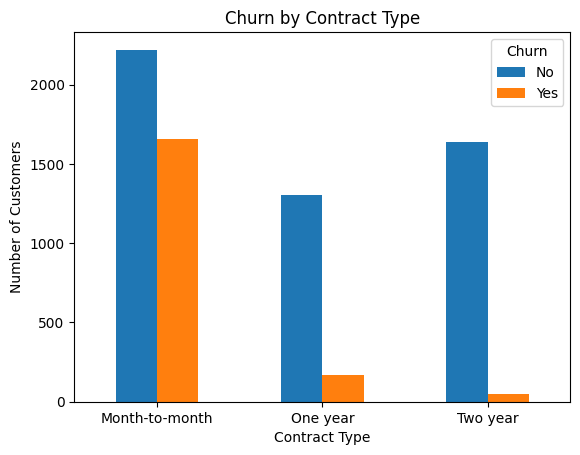

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

contract_churn = pd.crosstab(df["Contract"], df["Churn"])

contract_churn.plot(kind="bar")

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

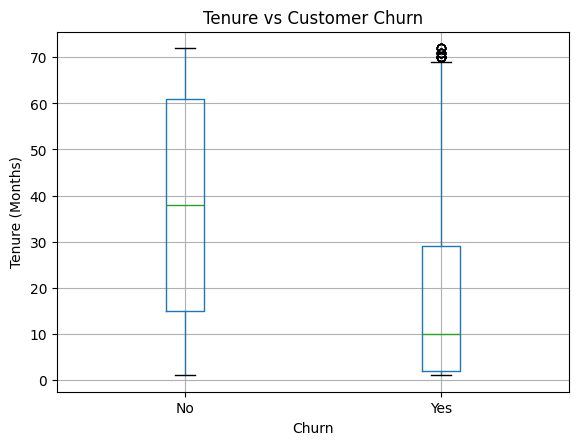

In [ ]:
import matplotlib.pyplot as plt

df.boxplot(column="tenure", by="Churn")

plt.title("Tenure vs Customer Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

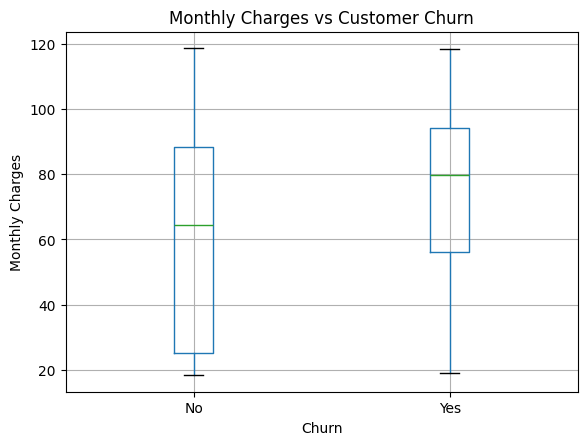

In [ ]:
import matplotlib.pyplot as plt

df.boxplot(column="MonthlyCharges", by="Churn")

plt.title("Monthly Charges vs Customer Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

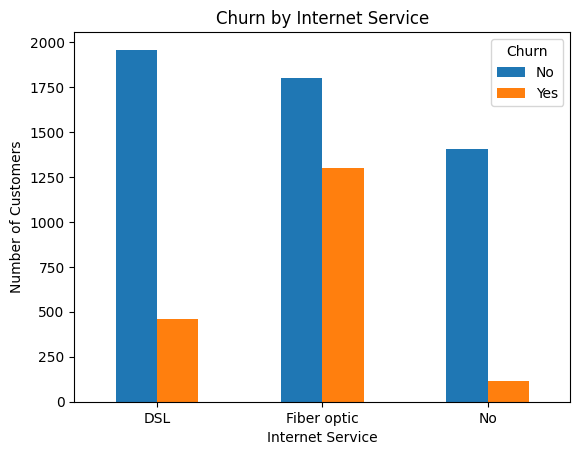

In [ ]:
internet_churn = pd.crosstab(df["InternetService"], df["Churn"])

internet_churn.plot(kind="bar")

plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

In [ ]:
churn_rate = df["Churn"].value_counts(normalize=True) * 100

print(churn_rate)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Convert Yes/No columns into numbers
df_model = df.copy()

le = LabelEncoder()

for col in df_model.select_dtypes(include="object").columns:
    if col != "customerID":
        df_model[col] = le.fit_transform(df_model[col])

# Remove Customer ID
df_model = df_model.drop("customerID", axis=1)

X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (5625, 19)
Testing Data: (1407, 19)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.7853589196872779

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


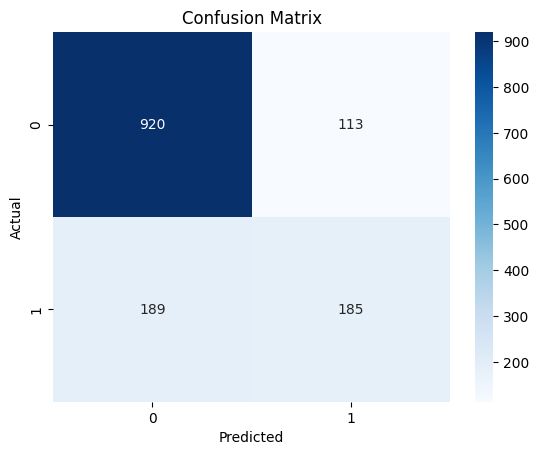

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Example customer prediction

sample_customer = X_test.iloc[[0]]

prediction = model.predict(sample_customer)[0]

if prediction == 1:
    print("Prediction: Customer is likely to CHURN")
else:
    print("Prediction: Customer is likely to STAY")


Prediction: Customer is likely to STAY


In [ ]:
# 1. Churn by Contract
print("=== Churn by Contract ===")
print(pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100)

# 2. Churn by Internet Service
print("\n=== Churn by Internet Service ===")
print(pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100)

# 3. Average Monthly Charges
print("\n=== Average Monthly Charges ===")
print(df.groupby("Churn")["MonthlyCharges"].mean())

# 4. Average Tenure
print("\n=== Average Tenure ===")
print(df.groupby("Churn")["tenure"].mean())

=== Churn by Contract ===
Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665

=== Churn by Internet Service ===
Churn                   No        Yes
InternetService                      
DSL              81.001656  18.998344
Fiber optic      58.107235  41.892765
No               92.565789   7.434211

=== Average Monthly Charges ===
Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

=== Average Tenure ===
Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

scaled_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000)
)

scaled_model.fit(X_train, y_train)

y_pred_scaled = scaled_model.predict(X_test)

print("Model Accuracy:", accuracy_score(y_test, y_pred_scaled))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_scaled))

Model Accuracy: 0.7853589196872779

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



In [ ]:
# Sample customer prediction

sample_customer = X_test.iloc[[0]]

prediction = scaled_model.predict(sample_customer)[0]

if prediction == 1:
    print("Prediction: Customer is likely to CHURN")
else:
    print("Prediction: Customer is likely to STAY")

Prediction: Customer is likely to STAY


In [ ]:
probability = scaled_model.predict_proba(sample_customer)[0][1]

print("Probability of Churn:", round(probability * 100, 2), "%")

Probability of Churn: 0.48 %


In [ ]:
print("=== HIGH RISK CONTRACT ===")
print(
    pd.crosstab(df["Contract"], df["Churn"], normalize="index")["Yes"]
    .sort_values(ascending=False)
)

print("\n=== HIGH RISK INTERNET SERVICE ===")
print(
    pd.crosstab(df["InternetService"], df["Churn"], normalize="index")["Yes"]
    .sort_values(ascending=False)
)

print("\n=== AVERAGE MONTHLY CHARGES ===")
print(df.groupby("Churn")["MonthlyCharges"].mean())

print("\n=== AVERAGE TENURE ===")
print(df.groupby("Churn")["tenure"].mean())

=== HIGH RISK CONTRACT ===
Contract
Month-to-month    0.427097
One year          0.112772
Two year          0.028487
Name: Yes, dtype: float64

=== HIGH RISK INTERNET SERVICE ===
InternetService
Fiber optic    0.418928
DSL            0.189983
No             0.074342
Name: Yes, dtype: float64

=== AVERAGE MONTHLY CHARGES ===
Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

=== AVERAGE TENURE ===
Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64


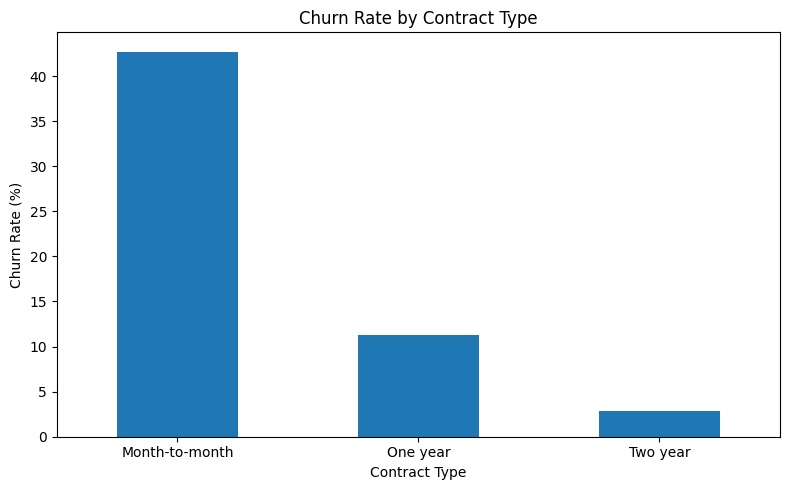

In [ ]:
import matplotlib.pyplot as plt

contract_rates = (
    pd.crosstab(df["Contract"], df["Churn"], normalize="index")["Yes"] * 100
)

plt.figure(figsize=(8,5))
contract_rates.plot(kind="bar")
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
print("Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Shape: (7032, 21)

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate Rows: 0

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessB

In [ ]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
